# Importando

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [ ]:
df = pd.read_csv('table_ABSENTEEISM.csv', sep=';', encoding='UTF-8')
df.head()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours
0,11,26,7,3,1,289,36,13,33,"239,554",...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,"239,554",...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,"239,554",...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,"239,554",...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,"239,554",...,0,1,2,1,0,1,90,172,30,2


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ID                               740 non-null    int64 
 1   Reason_for_absence               740 non-null    int64 
 2   Month_of_absence                 740 non-null    int64 
 3   Day_of_the_week                  740 non-null    int64 
 4   Seasons                          740 non-null    int64 
 5   Transportation_expense           740 non-null    int64 
 6   Distance_from_Residence_to_Work  740 non-null    int64 
 7   Service_time                     740 non-null    int64 
 8   Age                              740 non-null    int64 
 9   Work_load_Average_day            740 non-null    object
 10  Hit_target                       740 non-null    int64 
 11  Disciplinary_failure             740 non-null    int64 
 12  Education                        740

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,94.587838,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,3.779313,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,81.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,93.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,95.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,97.000000,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,100.000000,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


# Tratamento

In [12]:
# Adicionando a coluna estação do ano

def mes_para_periodo(mes):
    if mes in [12, 1, 2]:
        return 'Verão'
    elif mes in [3, 4, 5]:
        return 'Outono'
    elif mes in [6, 7, 8]:
        return 'Inverno'
    else:
        return 'Primavera'

df['Season_from_month'] = df['Month_of_absence'].apply(mes_para_periodo)

# Análises de distribuição

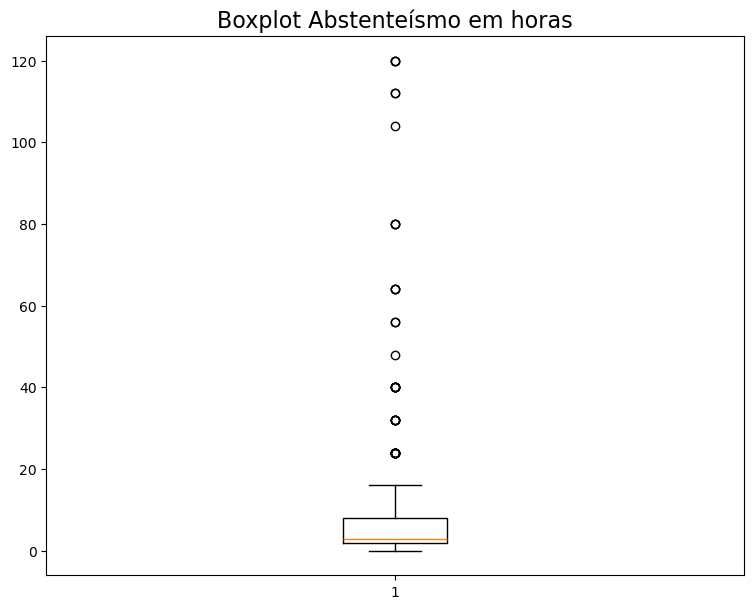

In [3]:
# Box plot abstenteismo em horas

fig, ax = plt.subplots(figsize = (9,7))

ax.set_title("Boxplot Abstenteísmo em horas", fontsize = 16)

ax.boxplot(df['Absenteeism_time_in_hours'])

plt.show()

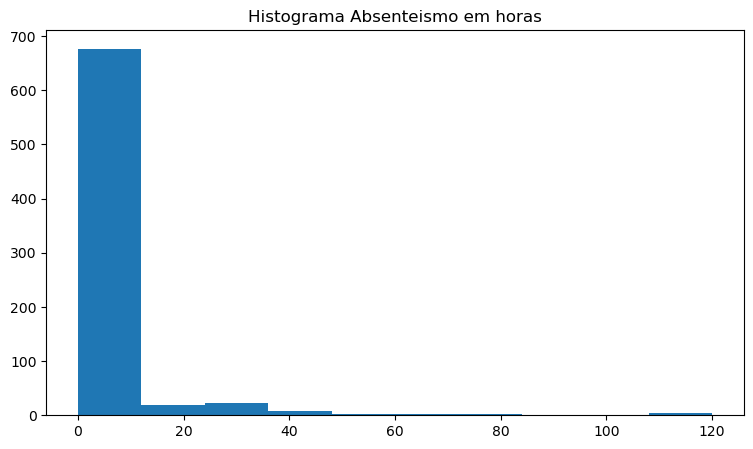

In [33]:
fig, ax = plt.subplots(figsize = (9,5))

ax.set_title("Histograma Absenteismo em horas")

ax.hist(df['Absenteeism_time_in_hours'])

plt.show()

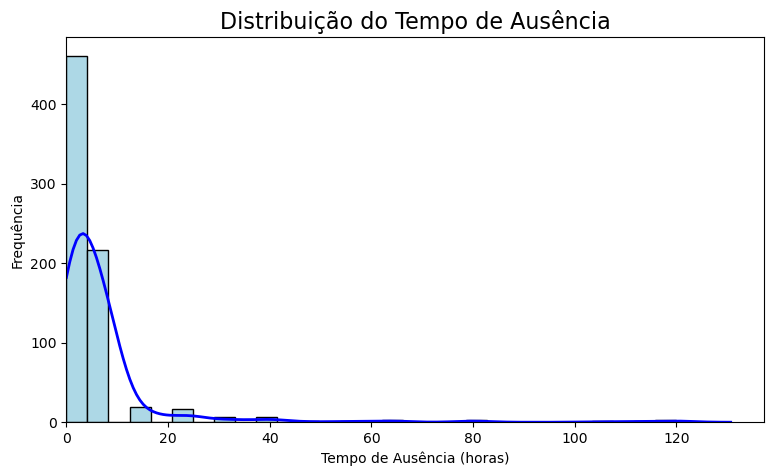

In [23]:
# Histrograma principal

data = df['Absenteeism_time_in_hours']

bins = np.linspace(0, data.max(), 30)

fig, ax = plt.subplots(figsize = (9,5))

# Histograma em frequência
counts, bins, _ = ax.hist(data, bins=bins, color='lightblue', edgecolor='black')

# KDE escalada para frequência
kde = sns.kdeplot(data, color='blue', linewidth=2, clip=(0, None))

# Ajustar escala da KDE
line = kde.get_lines()[0]
line.set_ydata(line.get_ydata() * len(data) * (bins[1] - bins[0]))

plt.xlim(left=0)

ax.set_title('Distribuição do Tempo de Ausência', fontsize = 16)
ax.set_xlabel('Tempo de Ausência (horas)')
ax.set_ylabel('Frequência')

# salvar imagem
fig.savefig('figures/histograma_absenteismo.png', 
            dpi=300, 
            bbox_inches='tight')

plt.show()


## Box plots seaborn 

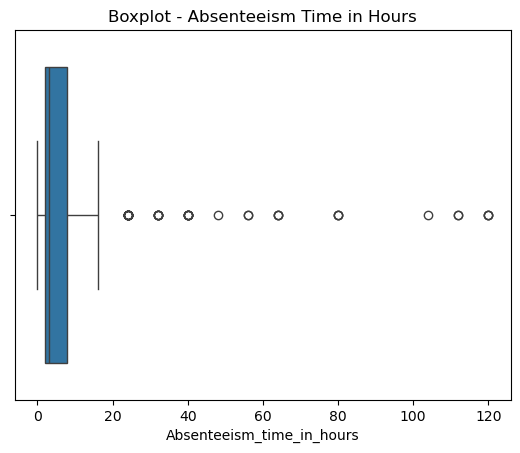

In [6]:
sns.boxplot(x=df['Absenteeism_time_in_hours'])

plt.title('Boxplot - Absenteeism Time in Hours')
plt.show()

## Para várias variáveis de uma vez

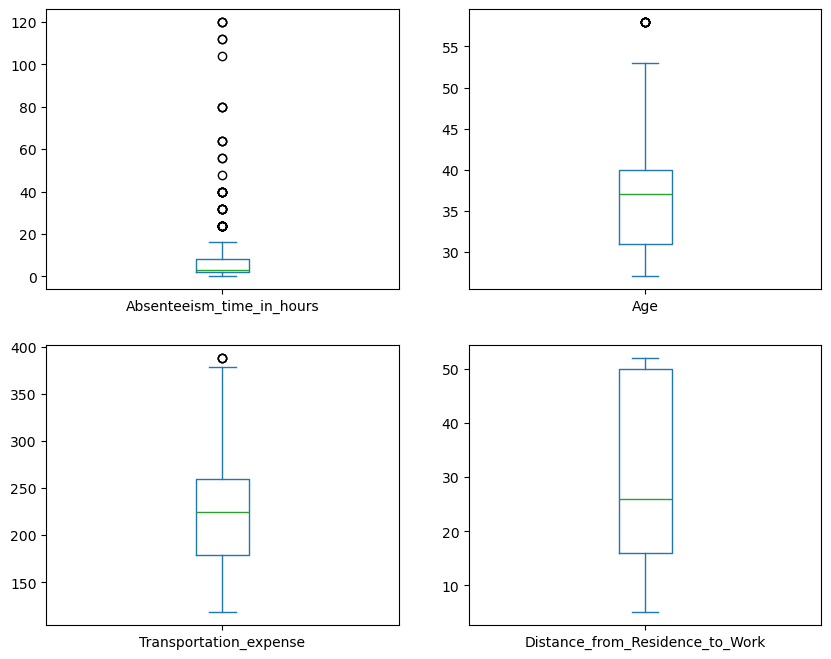

In [9]:
cols = [
    'Absenteeism_time_in_hours',
    'Age',
    'Transportation_expense',
    'Distance_from_Residence_to_Work'
]

df[cols].plot(kind='box', subplots=True, layout=(2,2), figsize=(10,8))
plt.show()

## Boxplot por categoria

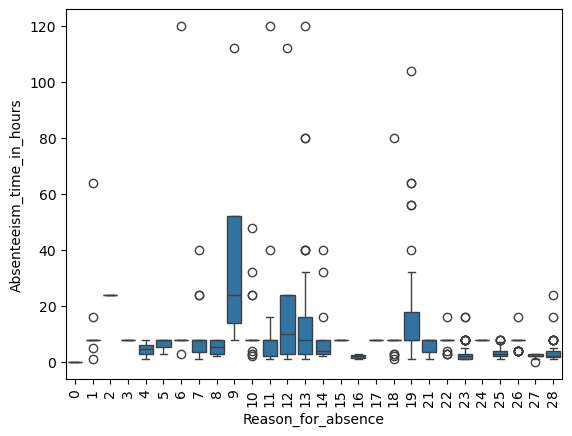

In [10]:
sns.boxplot(
    x='Reason_for_absence',
    y='Absenteeism_time_in_hours',
    data=df
)

plt.xticks(rotation=90)
plt.show()

## Gráfico de barras para Reason_for_absence

In [24]:
# Dicionário de tradução
motivos = {
    1: 'Doenças infecciosas',
    2: 'Neoplasias',
    3: 'Doenças do sangue',
    4: 'Doenças endócrinas',
    5: 'Transtornos mentais',
    6: 'Sistema nervoso',
    7: 'Olhos',
    8: 'Ouvido',
    9: 'Sistema circulatório',
    10: 'Sistema respiratório',
    11: 'Sistema digestivo',
    12: 'Pele',
    13: 'Musculoesquelético',
    14: 'Geniturinário',
    15: 'Gravidez/parto',
    16: 'Perinatais',
    17: 'Malformações',
    18: 'Sintomas não classificados',
    19: 'Lesões',
    20: 'Causas externas',
    21: 'Fatores de saúde',
    22: 'Acompanhamento',
    23: 'Consulta médica',
    24: 'Doação de sangue',
    25: 'Exame laboratorial',
    26: 'Injustificada',
    27: 'Fisioterapia',
    28: 'Consulta odontológica'
}

In [25]:
# garantir que o código é numérico (evita "13" como string)
df['Reason_for_absence'] = pd.to_numeric(df['Reason_for_absence'], errors='coerce').astype('Int64')

# frequência REAL (base inteira), garantindo todos os códigos 1..28
freq = (
    df['Reason_for_absence']
    .value_counts()
    .reindex(motivos.keys(), fill_value=0)  # inclui os 28 mesmo que algum tenha 0
    .sort_values(ascending=False)           # maior -> menor
)

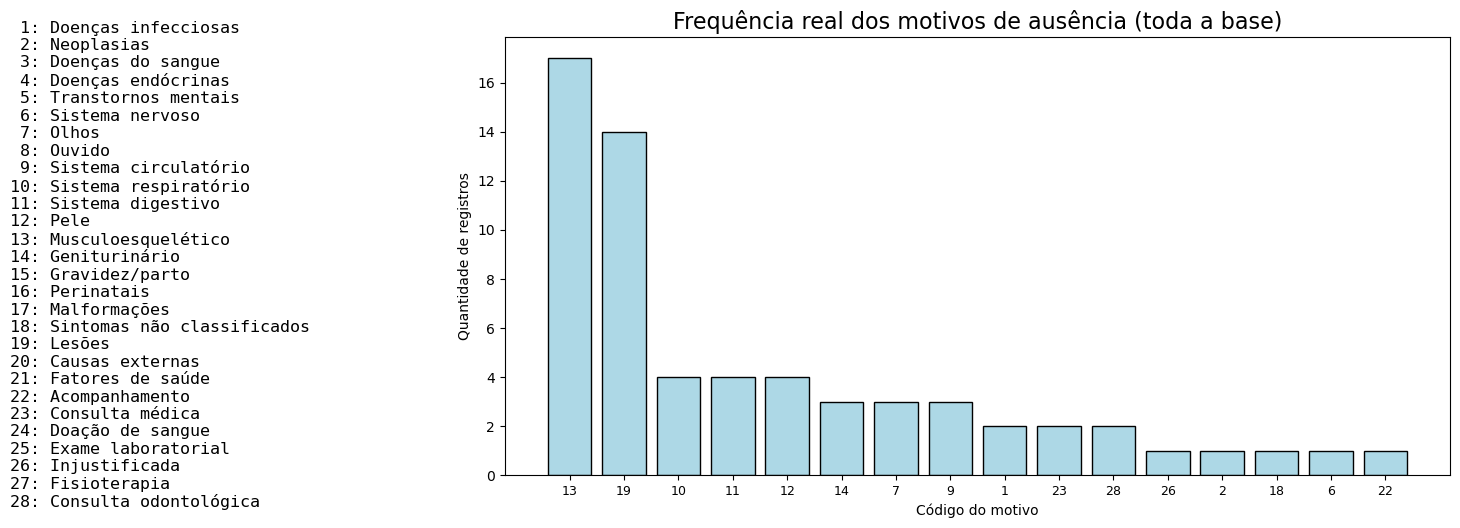

In [74]:
# plot: eixo X só com códigos
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(freq.index.astype(str), freq.values, color='lightblue', edgecolor='black')

ax.set_title('Frequência real dos motivos de ausência (toda a base)', fontsize = 16)
ax.set_xlabel('Código do motivo')
ax.set_ylabel('Quantidade de registros')
ax.tick_params(axis='x', rotation=0, labelsize=9)  # códigos “retinhos”

# ---- legenda à ESQUERDA (códigos -> descrições) ----
legenda = "\n".join([f"{k:>2}: {v}" for k, v in motivos.items()])

# abre espaço à esquerda para caber a legenda
fig.subplots_adjust(left=0.35, right=0.98, bottom=0.15)

# coloca o texto da legenda no lado esquerdo
fig.text(
    0.02, 0.5, legenda,
    fontsize=12, va='center', ha='left',
    family='monospace'
)

# salvar
plt.savefig('figures/frequencia_motivos_real.png', 
            dpi=300, 
            bbox_inches='tight'
            )

plt.show()

# Identificar outliers com IQR

In [36]:
Q1 = df['Absenteeism_time_in_hours'].quantile(0.25)
Q3 = df['Absenteeism_time_in_hours'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['Absenteeism_time_in_hours'] < limite_inferior) |
    (df['Absenteeism_time_in_hours'] > limite_superior)
]

print(outliers)

     ID  Reason_for_absence  Month_of_absence  Day_of_the_week  Seasons  \
8    14                  19                 7                2        1   
22   10                  13                 8                2        1   
49   15                  14                 9                2        4   
85   14                  10                11                2        4   
87   15                  14                11                2        4   
96   11                   7                11                4        4   
99   34                  19                12                3        4   
104  34                  19                12                3        4   
163  20                  13                 3                6        2   
164  17                  11                 3                2        2   
173   3                  13                 3                3        2   
187  24                  13                 4                4        3   
191   3                  

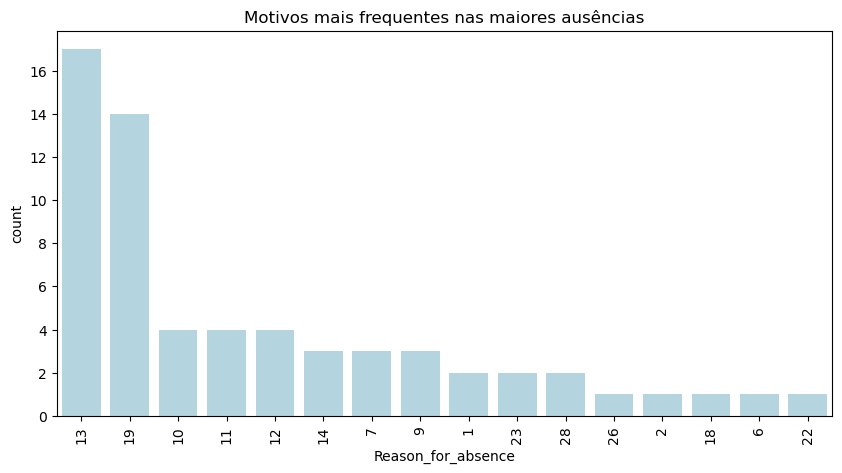

In [75]:
q3 = df['Absenteeism_time_in_hours'].quantile(0.75)

top = df[df['Absenteeism_time_in_hours'] > q3]
freq = top['Reason_for_absence'].value_counts()

import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    x='Reason_for_absence',
    data=top,
    order=top['Reason_for_absence'].value_counts().index,
    color='lightblue'
)

plt.title('Motivos mais frequentes nas maiores ausências')
plt.xticks(rotation=90)

plt.show()

# Winsorização

In [38]:
horas_absenteismo_winsorizado = df['Absenteeism_time_in_hours'].clip(
    lower=limite_inferior,
    upper=limite_superior
)

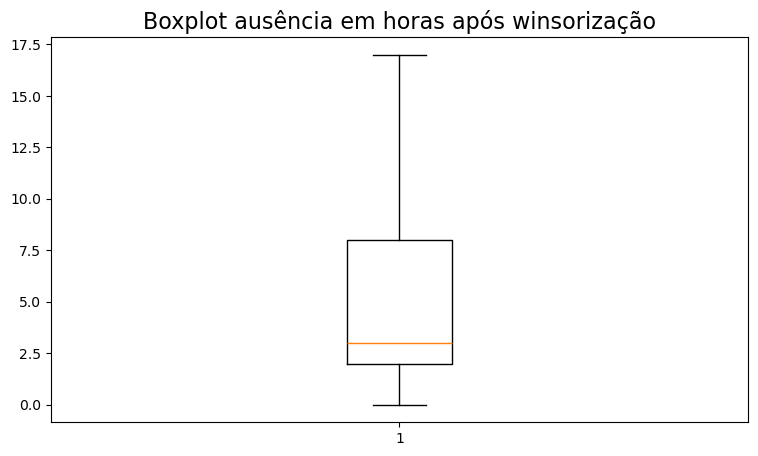

In [40]:
fig, ax = plt.subplots(figsize = (9,5))

ax.set_title("Boxplot ausência em horas após winsorização", fontsize = 16)

ax.boxplot(horas_absenteismo_winsorizado)

fig.savefig('figures/Boxplot_Absenteismo_após_winsorização.png', 
            dpi=300,
            bbox_inches = 'tight')

plt.show()

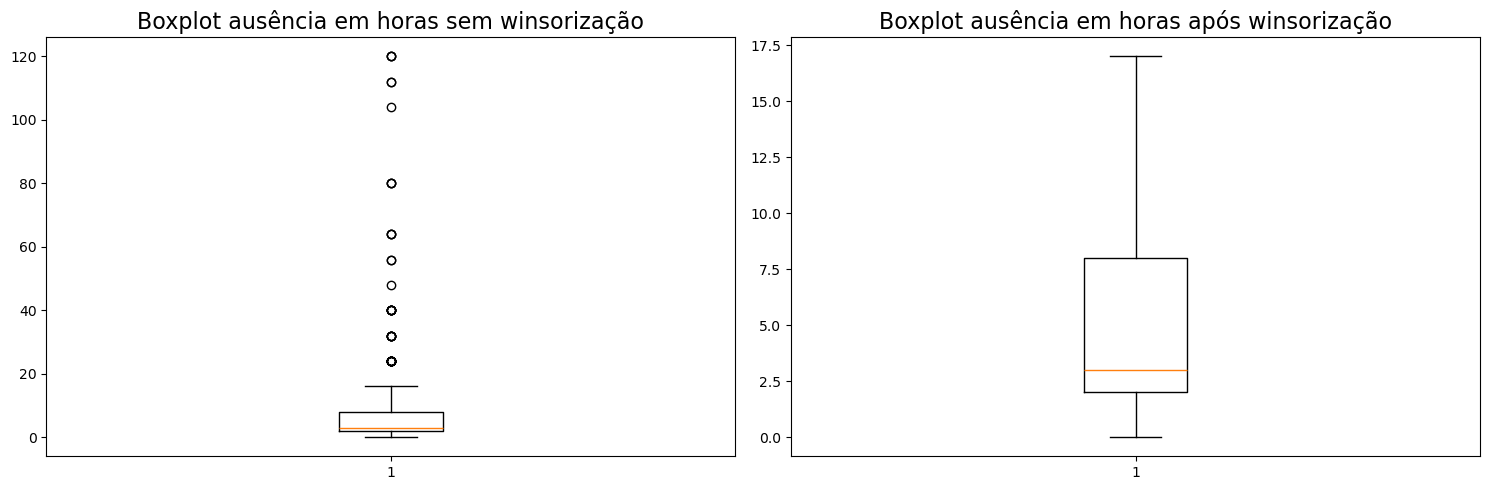

In [41]:
fig, ax = plt.subplots(figsize = (15,5),nrows=1, ncols=2)

ax[1].set_title("Boxplot ausência em horas após winsorização", fontsize = 16)

ax[1].boxplot(horas_absenteismo_winsorizado)

ax[0].set_title("Boxplot ausência em horas sem winsorização", fontsize = 16)

ax[0].boxplot(df['Absenteeism_time_in_hours'])

fig.tight_layout()

fig.savefig('figures/Comparação_Boxplots_winsorização.png', 
            dpi=300,
            bbox_inches = 'tight')

plt.show()

# Gráficos de dispersão

In [ ]:
df_numerico = df[['Transportation_expense','Distance_from_Residence_to_Work','Service_time','Age','Hit_target','Education','Son','Social_drinker','Social_smoker','Pet','Weight','Height','Body_mass_index','Absenteeism_time_in_hours']].copy()

matriz = df_numerico.corr(method='pearson')
print(matriz)

                                 Transportation_expense  \
Transportation_expense                         1.000000   
Distance_from_Residence_to_Work                0.262183   
Service_time                                  -0.349887   
Age                                           -0.227542   
Hit_target                                    -0.080193   
Education                                     -0.055065   
Son                                            0.383001   
Social_drinker                                 0.145117   
Social_smoker                                  0.044356   
Pet                                            0.400080   
Weight                                        -0.207435   
Height                                        -0.194496   
Body_mass_index                               -0.136517   
Absenteeism_time_in_hours                      0.027585   

                                 Distance_from_Residence_to_Work  \
Transportation_expense                        

In [ ]:
corr_linha = df_numerico.corr(method='pearson')['Absenteeism_time_in_hours']

In [63]:
corr_linha = corr_linha.to_frame().T

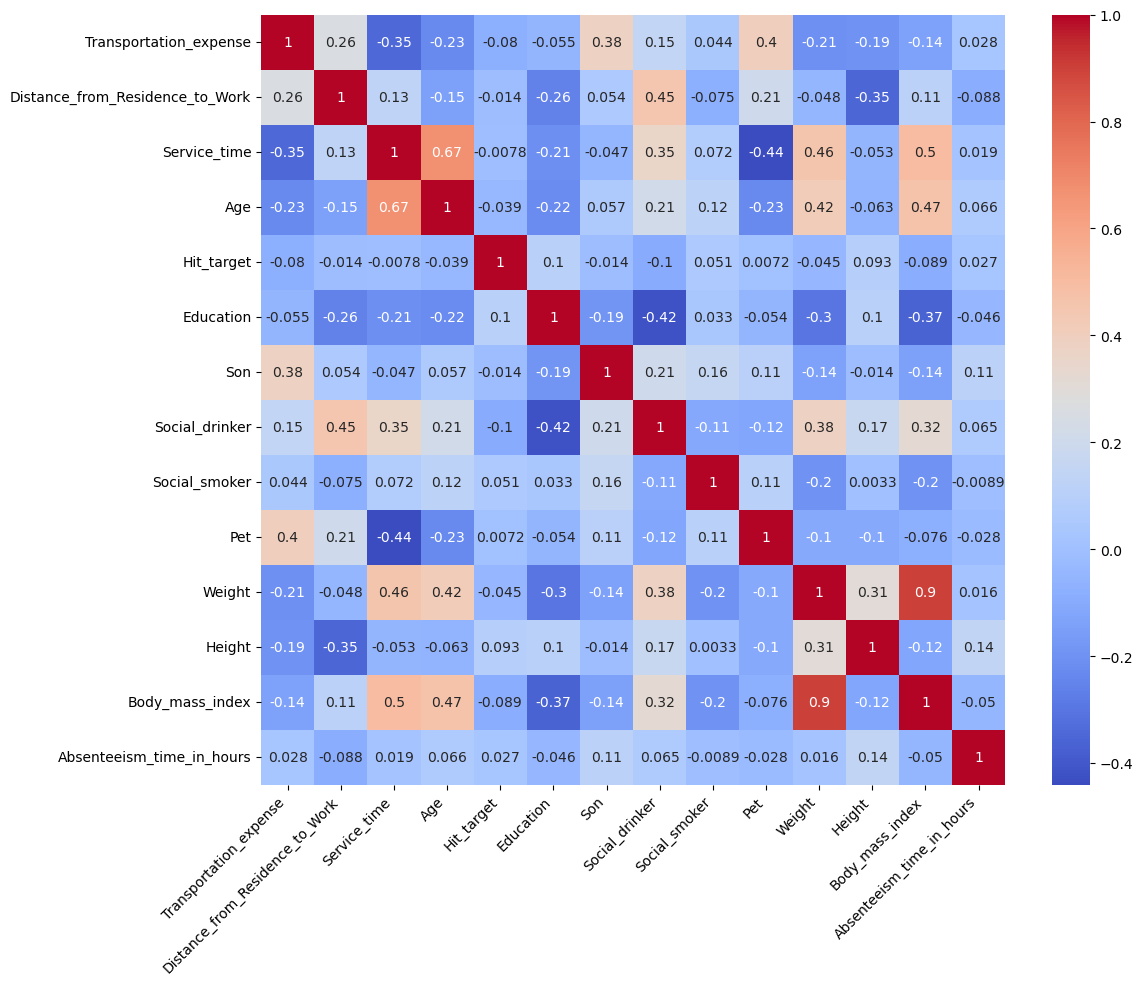

In [73]:
plt.figure(figsize=(12,10))
sns.heatmap(matriz, 
            cmap='coolwarm',
            annot=True,
            )

plt.savefig('figures/Heatmap.png', 
            dpi=300,
            bbox_inches = 'tight')

plt.xticks(rotation=45, ha='right') 

plt.show()